Bartlett's P-value: 0.0
KMO Score: 0.9458553862958632


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


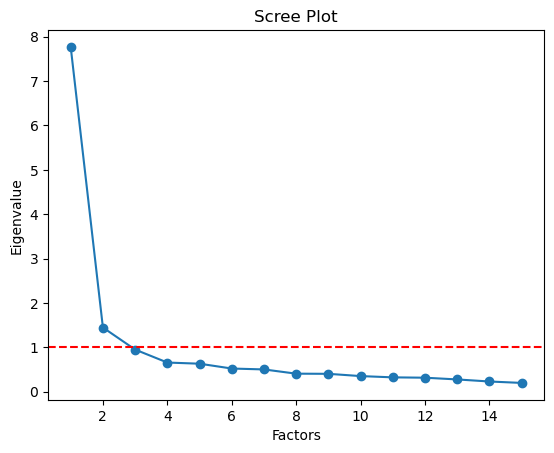

Optimal number of factors based on Kaiser Criterion: 2

--- Top items for Factor_1 ---
Q11    0.741275
Q12    0.730020
Q6     0.726661
Q1     0.712994
Q2     0.696392
Name: Factor_1, dtype: float64

--- Top items for Factor_2 ---
Q8     0.847690
Q3     0.824278
Q13    0.785851
Q9     0.449344
Q4     0.409956
Name: Factor_2, dtype: float64


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# 1. Load the data
df = pd.read_csv('C:/Users/amaca253/Documents/datomatisation/datomatisation-dev/data/demo_data/conspiracy/data.csv')
questions = df[[f'Q{i}' for i in range(1, 16)]].dropna()

# 2. Check for Factorability
chi_square_value, p_value = calculate_bartlett_sphericity(questions)
kmo_all, kmo_model = calculate_kmo(questions)
print(f"Bartlett's P-value: {p_value}")
print(f"KMO Score: {kmo_model}")

# 3. Determine optimal number of factors (Eigenvalues > 1)
fa = FactorAnalyzer(rotation=None)
fa.fit(questions)
ev, v = fa.get_eigenvalues()

# Plot Scree Plot
plt.scatter(range(1, questions.shape[1]+1), ev)
plt.plot(range(1, questions.shape[1]+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

n_factors = sum(ev > 1)
print(f"Optimal number of factors based on Kaiser Criterion: {n_factors}")

# 4. Perform Factor Analysis
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(questions)

# 5. Get loadings and map to names
loadings = pd.DataFrame(fa.loadings_, 
                        index=questions.columns, 
                        columns=[f"Factor_{i+1}" for i in range(n_factors)])

# Display top items for each factor to name them
for col in loadings.columns:
    print(f"\n--- Top items for {col} ---")
    print(loadings[col].sort_values(ascending=False).head(5))